In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("time_series_60min_singleindex.csv")

In [4]:
df.head()

,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [6]:
df.columns

Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='object', length=300)

In [7]:
df.shape

(50401, 300)

In [14]:
de_columns = [col for col in df.columns if col.startswith('DE')]
print(len(de_columns))

41


In [15]:
print(de_columns)

['DE_load_actual_entsoe_transparency', 'DE_load_forecast_entsoe_transparency', 'DE_solar_capacity', 'DE_solar_generation_actual', 'DE_solar_profile', 'DE_wind_capacity', 'DE_wind_generation_actual', 'DE_wind_profile', 'DE_wind_offshore_capacity', 'DE_wind_offshore_generation_actual', 'DE_wind_offshore_profile', 'DE_wind_onshore_capacity', 'DE_wind_onshore_generation_actual', 'DE_wind_onshore_profile', 'DE_50hertz_load_actual_entsoe_transparency', 'DE_50hertz_load_forecast_entsoe_transparency', 'DE_50hertz_solar_generation_actual', 'DE_50hertz_wind_generation_actual', 'DE_50hertz_wind_offshore_generation_actual', 'DE_50hertz_wind_onshore_generation_actual', 'DE_LU_load_actual_entsoe_transparency', 'DE_LU_load_forecast_entsoe_transparency', 'DE_LU_price_day_ahead', 'DE_LU_solar_generation_actual', 'DE_LU_wind_generation_actual', 'DE_LU_wind_offshore_generation_actual', 'DE_LU_wind_onshore_generation_actual', 'DE_amprion_load_actual_entsoe_transparency', 'DE_amprion_load_forecast_entsoe_t

In [16]:
cols = ['utc_timestamp', 'DE_load_actual_entsoe_transparency',
        'DE_load_forecast_entsoe_transparency',
        'DE_solar_generation_actual',
        'DE_wind_generation_actual',
        'DE_LU_price_day_ahead']

df = df[cols]
df = df.dropna(subset=['DE_load_actual_entsoe_transparency'])
print(df.shape)
df.head()

(50400, 6)


,utc_timestamp,DE_load_actual_entsoe_transparency,DE_load_forecast_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_LU_price_day_ahead
1,2015-01-01T00:00:00Z,41151.0,39723.0,NaN,8852.0,NaN
2,2015-01-01T01:00:00Z,40135.0,38813.0,NaN,9054.0,NaN
3,2015-01-01T02:00:00Z,39106.0,38490.0,NaN,9070.0,NaN
4,2015-01-01T03:00:00Z,38765.0,38644.0,NaN,9163.0,NaN
5,2015-01-01T04:00:00Z,38941.0,38773.0,NaN,9231.0,NaN


In [18]:
import sqlite3

conn = sqlite3.connect('energy.db')
df.to_sql('energy', conn, if_exists='replace', index=False)
print("data imported to SQLite")
conn.close()

data imported to SQLite


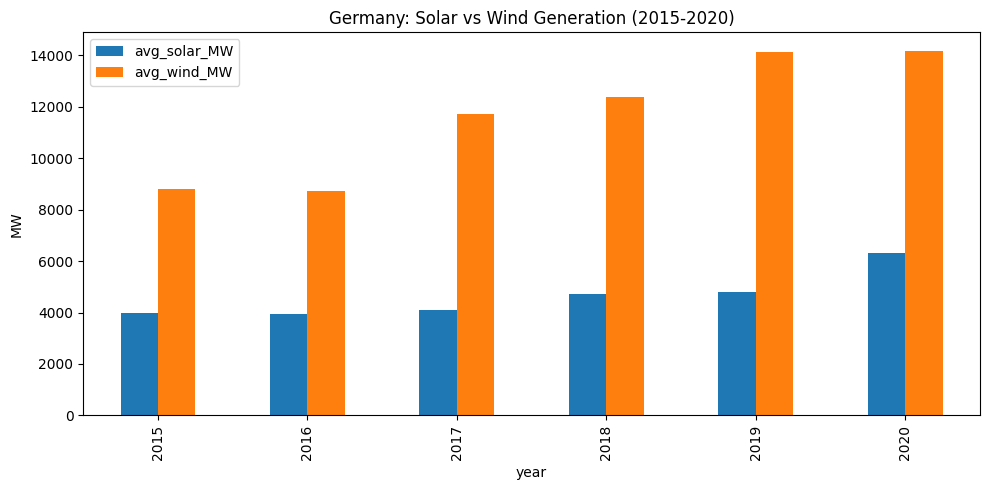

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('energy.db')

yearly = pd.read_sql("""
    SELECT strftime('%Y', utc_timestamp) AS year,
    ROUND(AVG(DE_load_actual_entsoe_transparency), 2) AS avg_load_MW,
    ROUND(AVG(DE_solar_generation_actual), 2) AS avg_solar_MW,
    ROUND(AVG(DE_wind_generation_actual), 2) AS avg_wind_MW
    FROM energy
    WHERE DE_load_actual_entsoe_transparency IS NOT NULL
    GROUP BY year ORDER BY year
""", conn)

yearly.plot(x='year', y=['avg_solar_MW', 'avg_wind_MW'], kind='bar', figsize=(10,5))
plt.title('Germany: Solar vs Wind Generation (2015-2020)')
plt.ylabel('MW')
plt.tight_layout()
plt.savefig('energy_chart.png')
plt.show()

In [21]:
# SQL Queries used in this project (DBeaver(SQLite))

# 1. Yearly average load, solar and wind generation
q1 = """
SELECT strftime('%Y', utc_timestamp) AS year,
    ROUND(AVG(DE_load_actual_entsoe_transparency), 2) AS avg_load_MW,
    ROUND(AVG(DE_solar_generation_actual), 2) AS avg_solar_MW,
    ROUND(AVG(DE_wind_generation_actual), 2) AS avg_wind_MW
FROM energy
WHERE DE_load_actual_entsoe_transparency IS NOT NULL
GROUP BY year ORDER BY year;
"""

# 2. Forecast error by year
q2 = """
SELECT strftime('%Y', utc_timestamp) AS year,
    ROUND(AVG(DE_load_actual_entsoe_transparency - DE_load_forecast_entsoe_transparency), 2) AS avg_forecast_error_MW
FROM energy
WHERE DE_load_actual_entsoe_transparency IS NOT NULL
    AND DE_load_forecast_entsoe_transparency IS NOT NULL
GROUP BY year ORDER BY year;
"""

# 3. Average consumption by month
q3 = """
SELECT strftime('%m', utc_timestamp) AS month,
    ROUND(AVG(DE_load_actual_entsoe_transparency), 2) AS avg_load_MW
FROM energy
WHERE DE_load_actual_entsoe_transparency IS NOT NULL
GROUP BY month ORDER BY avg_load_MW DESC;
"""

print("SQL queries defined.")

SQL queries defined.
